<center>
<h1>Optimización Cuántica para Asignación de Frecuencias en una Flota de Drones</h1>

<h3>Curso de Computación Cuántica, 2026-1</h3>

<h3>Facultad de Ingeniería</h3>

<h3>Universidad de Antioquia</h3>

Sebastián Castaño Quinchía
</center>




## 1. Contexto del Problema

Una empresa opera una flota de cinco (5) drones que realizan diferentes tareas simultáneas.

Debido a la proximidad entre algunos drones, es posible que se presenten interferencias si se utiliza la misma frecuencia de comunicación.

El problema consiste entonces en dividir los drones en dos grupos:

- Los que tendrán una frecuencia del **Canal A**.
- Y los que tendran otra frecuencia de **Canal B**.

de manera tal que los drones que presentan mayores niveles de interferencia utilicen frecuencias diferentes.

## 2. Representación Mediante Grafos

Considere la representación de la flota de drones, como un grafo ponderado no-dirigido, donde:

- Cada dron se representa mediante un vértice.
- Cada posible interferencia entre dos drones se representa mediante una arista ponderada.
- Los pesos de cada arista representan la intensidad de la interferencia.

## 3. Formulación del Problema Max-Cut

Defina una variable binaria:

$$
x_i \in \{0,1\}
$$

donde:

- $x_i = 0$: Corresponde al *i-ésimo* dron asignado al **Canal A**.
- $x_i = 1$: Corresponde al *i-ésimo* dron asignado al **Canal B**.

El objetivo es maximizar:

$$
f(x) = \sum_{(i,j)\in E} w_{ij}(x_i \oplus x_j)
$$

donde:

- $w_{ij}$ es el peso de interferencia.
- $x_i \oplus x_j$ vale 1 cuando los drones están en grupos distintos.


## 4. Actividades del Laboratorio

### 4.1. Desarrollo matemático y manual:  

4.1.1. Dada la matriz adyancencia asignada, dibuje a mano el grafo correspondiente, identificando los nodos para cada dron, y el peso de interferencia entre drones.

$$ A = \begin{bmatrix}
0 & 7 & 5 & 8 & 6 \\
7 & 0 & 9 & 4 & 3 \\
5 & 9 & 0 & 7 & 8 \\
8 & 4 & 7 & 0 & 6 \\
6 & 3 & 8 & 6 & 0
\end{bmatrix} $$

> A partir de esta matriz simétrica y con diagonal nula, se construye un grafo no dirigido $G=(V,E)$, donde:
>
> $V=\{D_1, D_2, D_3, D_4, D_5 \}$ es el conjunto de vértices, representados por los drones.
>
> $E=\{I_{ij}\}, i \neq j$, es el conjunto de aristas, que representan las posibles interferencias entre los drones $D_i$ y $D_j$, y los pesos $w_{ij}$ la intensidad de interferencia.

4.1.2. Dado el grafo, obtenga la función objetivo $f(x)$ del problema de Max-Cut, en términos polinomiales.

> El problema de optimización combinatoria Max-Cut busca dividir el grafo no dirigido en dos subgrafos maximizando la suma del número o el peso de las aristas que conectan los nodos en ambos subgrafos.
>
> Para este problema de drones, como la interferencia entre drones queda mitigada cuando estos usan canales de comunicación de frecuencia distintos, se busca dividir el conjunto de drones en dos grupos de frecuencias (Canal A y Canal B) de tal manera que las interferencias más intensas ocurran entre drones que operan en canales diferentes, mitigando así la interferencia en los canales de comunicación. La idea es que si dos drones están muy cerca y podrían interferirse, es preferible que estén en canales distintos.
>
> Un subgrafo corresponde a los drones que se comunican con frecuencia en el  **Canal A** y el otro los drones con frecuencia en el **Canal B**.
>
> Definimos una variable binaria para cada nodo:
>
> $$x_i = \begin{cases} 0 & \text{si } D_i \in \text{Canal A} \\ 1 & \text{si } D_i \in \text{Canal B} \end{cases} $$
>
> Siendo $i=1,2,3,4,5$.
>
> Función objetivo a maximizar:
>
> $$f(x) = \sum_{i<j} w_{ij} ( x_i \oplus
 x_j )= \sum_{i<j} w_{ij} (x_i + x_j - 2 x_i x_j)$$
>
> Sustituyendo los valores de la matriz:
>
> $$f(x) = 7(x_1+x_2-2x_1x_2) + 5(x_1+x_3-2x_1x_3) + 8(x_1+x_4-2x_1x_4) + 6(x_1+x_5-2x_1x_5) + 9(x_2+x_3-2x_2x_3) + 4(x_2+x_4-2x_2x_4) + 3(x_2+x_5-2x_2x_5) + 7(x_3+x_4-2x_3x_4) + 8(x_3+x_5-2x_3x_5) + 6(x_4+x_5-2x_4x_5)$$
>
> $$f(x) = 26x_1 + 23x_2 + 29x_3 + 25x_4 + 23x_5 - 14x_1x_2 - 10x_1x_3 - 16x_1x_4 - 12x_1x_5 - 18x_2x_3 - 8x_2x_4 - 6x_2x_5 - 14x_3x_4 - 16x_3x_5 - 12x_4x_5$$

4.1.3. Construya la matriz QUBO correspondiente. Presente el desarrollo matemático requerido.

> Este problema de optimización lo podemos mapear a una formlación QUBO donde se optimice una función cuadrática objetivo definida como:
>
> $$f(x) = \mathbf x^T \mathbf Q \mathbf x = \sum_i Q_{ii} x_i + \sum_{i<j} Q_{ij} x_i x_j$$
>
> Queremos construir la matriz $Q$ a partir de la función objetivo del problema Max Cut, que se desea optimizar por medio de una formulación QUBO.
>
> Como $x_i x_j = x_j x_i$, contrastando la función objetivo con la notación matricial previa de $f(x)$, obtenemos:
>
> $$ Q = \begin{bmatrix}
26 & -7 & -5 & -8 & -6 \\
-7 & 23 & -9 & -4 & -3 \\
-5 & -9 & 29 & -7 & -8 \\
-8 & -4 & -7 & 25 & -6 \\
-6 & -3 & -8 & -6 & 23
\end{bmatrix} $$

4.1.4. Realice la conversión al Hamiltoniano Ising.

> Para trasladar el problema de optimización de configuración de drones, a una formulación cuántica debemos codificar las variables binarias $x_i \in \{0,1\}$ a espines $s_i$ cuyos posibles valores son $\{-1, +1\}$. Para esto aplicamos la transformación:
>
> $$x_i = \frac{1-s_i}{2}$$
>
> Que transforma la función $f(x)$ de la notación de Max-Cut en:
>
> $$f(s) = \sum_{i<j} \frac{w_{ij}}2 (1-s_i s_j) $$
>
> Desde la formulación Max Cut se desea maximizar la función $f(x)$, y por ende, también $f(s)$.
>
> Dado que en un modelo de optimización de Ising, el objetivo es encontrar la configuración de espines que minimice el valor de energía total del sistema, esto es, minimizar el Hamiltoniano del sistema.
>
> Contrastando esta función objetivo a un problema de minimización de energía, se encuentra que el Hamiltoniano a minimizar es de la forma:
>
> $$H(s) = - \sum_{i<j} \frac{w_{ij}}2 (1-s_i s_j) $$
>
> Luego, para hacer esta optimización por medio de circuitos cuánticos, se requiere la compuerta $\widehat Z$ que actúa sobre la base de qubits $\{|0 \rangle, |1 \rangle \}$ que producen como autovalores respectivamente los espines $\{+1, -1\}$. Así, el operador Hamiltoniano se escribe como:
>
> $$\widehat H(\widehat Z) = - \sum_{i<j} \frac{w_{ij}}2 (1- \widehat Z_i \widehat Z_j)$$
>
> * $\sum_{i<j} w_{ij} = 7+5+8+6+9+4+3+7+8+6 = 63$
>
> $$H = - \frac{63}2 I + \frac12 \left( 7Z_1Z_2 + 5Z_1Z_3 + 8Z_1Z_4 + 6Z_1Z_5 + 9Z_2Z_3 + 4Z_2Z_4 + 3Z_2Z_5 + 7Z_3Z_4 + 8Z_3Z_5 + 6Z_4Z_5 \right)$$
<!-- >
> Así, el objetivo es $\min H$ para encontrar la configuración de energía mínima. -->

### 4.2. Implementación del sistema y su solución en Pennylane:  

Realice la implementación del presente problema, y su solución, en un Notebook basado en Pennylane considerando los siguientes elementos:

4.2.1. Elabore el grafo de la matriz de adyacencia asignada. Si desea, puede utilizar el segmento de código para dibujar grafos presente en el tutorial (**no realice** la implementación de permutaciones descrita en dicho tutorial):

* [An Equivariant Graph Embedding](https://pennylane.ai/demos/tutorial_equivariant_graph_embedding/)

4.2.2. Implemente la solución del problema de **Max-cut** descrito, mediante una de las siguientes opciones:

* [**Opción 1:** VQE (Variational Quantum Eigensolver)](https://github.com/gpatigno/QC_2026/blob/main/PR_FINAL/OpcionVQE.md)

* [**Opción 2:** QAOA (Quantum Approximate Optimization Algorithm)](https://github.com/gpatigno/QC_2026/blob/main/PR_FINAL/OpcionQAOA.md)

In [ ]:
!pip install pennylane    &> /dev/null

In [ ]:
from pennylane import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pennylane as qml

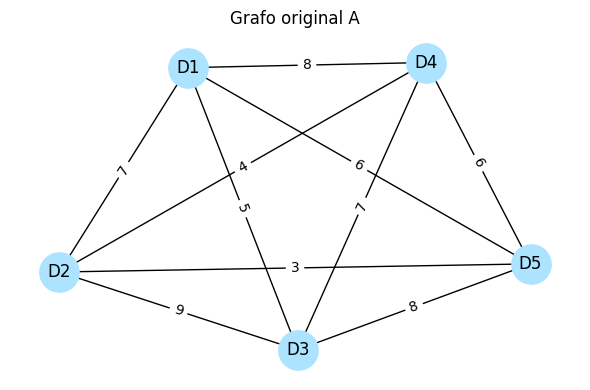

In [ ]:
A = np.array([
    [0, 7, 5, 8, 6],
    [7, 0, 9, 4, 3],
    [5, 9, 0, 7, 8],
    [8, 4, 7, 0, 6],
    [6, 3, 8, 6, 0]
])

# ------------ Grafo -----------------------
node_labels_1 = {i: f'D{i+1}' for i in range(len(A))}

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)

A_plot = A.copy()
np.fill_diagonal(A_plot, 0)
G1 = nx.Graph(A_plot)
pos1 = nx.spring_layout(G1, seed=1)
nx.draw(G1, pos1, labels=node_labels_1, ax=ax,
        node_size=800, node_color="#ACE3FF")
nx.draw_networkx_edge_labels(G1, pos1,
    edge_labels=nx.get_edge_attributes(G1, 'weight'), ax=ax)
# nx.draw_networkx_labels(G1, pos1, labels=node_labels, ax=ax)
ax.set_title("Grafo original A")

fig.tight_layout()

#### Opción 2: QAOA (Variational Quantum Eigensolver)

1. Implemente el **Hamiltoniano de costo** encontrado a mano en el item **4.1.4.** del **README.md**.

> $$H_C = - \frac{63}2 I + \frac12 \left( 7Z_1Z_2 + 5Z_1Z_3 + 8Z_1Z_4 + 6Z_1Z_5 + 9Z_2Z_3 + 4Z_2Z_4 + 3Z_2Z_5 + 7Z_3Z_4 + 8Z_3Z_5 + 6Z_4Z_5 \right)$$
>
> El sistema estará representado por 5 qubits $q_i$ asociados a los drones.

2. Defina el **Hamiltoniano mezclador** adecuado para el número de qubits requeridos para el problema de Max-cut descrito.

> A cada dron se le asigna un qubit. El Hamiltoniano mezclador explora el espacio de búsqueda, y se define aplicando una compuerta de Pauli $X$ a cada qubit:
>
> $$H_M = \sum_i^5 X_i$$

3. Implemente el circuito cuántico para dicho problema, con las capas QAOA respectivas (considere *p=1*). Recuerde definir el estado cuántico de entrada para su circuito.

> El operador de evolución conjunto para el sistema está dado como:
>
> $$\mathrm U (\beta, \gamma) = e^{-i \beta H_M} e^{-i \gamma H_C}$$
>
> Inicializando el sistema en el estado:
>
> $$|+ \rangle^{\otimes 5} = \frac{1}{\sqrt{2^5}} \sum_i |q_i \rangle$$
>
> Así, para una profundidad circuital $p$, el estado variacional QAOA (ansantz) se construye como la evolución $p$ veces del estado inicial:
>
> $$|\psi (\beta, \gamma) \rangle^{\otimes 5} = \prod_{k=1}^{p} e^{-i \beta_k H_M} e^{-i \gamma_k H_C} |+ \rangle^{\otimes 5}$$

4. Dibuje el circuito cuántico completo para una muestra específica de los parametros de dicho circuito. Explique y justifique las compuertas presentes en dicho circuito.

5. Seleccione e implemente un optimizador apropiado para dicho problema.

> Los parámetros $\beta$ y $\gamma$ son optimizados clásicamente minimizando el valor esperado del Hamiltoniano de costo.
>
> $$\min \langle \psi(\beta, \gamma) | H_c | \psi(\beta, \gamma) \rangle$$
>
> El valor mínimo de esta energía se da en la asignación de frecuencias a los drones que produce el mayor corte del grafo.
>
> Utilizamos como optimizador Adam por su versatilidad y suavidad con el gradiente descendente.

6. Realice el proceso de minimizar la energía esperada del **Hamiltoniano de costo**.

7. Obtenga y presenta los parámetros variacionales que minimizan dicha energía.

In [ ]:
## Implementación con QAOA

dev = qml.device("default.qubit", wires=5)

# ------------ Hamiltoniano de costo -------------------------
coefs = [-0.5*63, 0.5*7, 0.5*5, 0.5*8, 0.5*6, 0.5*9, 0.5*4, 0.5*3, 0.5*7, 0.5*8, 0.5*6]

observables = [
    qml.Identity(0),
    qml.PauliZ(0)@qml.PauliZ(1),
    qml.PauliZ(0)@qml.PauliZ(2),
    qml.PauliZ(0)@qml.PauliZ(3),
    qml.PauliZ(0)@qml.PauliZ(4),
    qml.PauliZ(1)@qml.PauliZ(2),
    qml.PauliZ(1)@qml.PauliZ(3),
    qml.PauliZ(1)@qml.PauliZ(4),
    qml.PauliZ(2)@qml.PauliZ(3),
    qml.PauliZ(2)@qml.PauliZ(4),
    qml.PauliZ(3)@qml.PauliZ(4)
]
H_cost = qml.Hamiltonian(coefs, observables)

# ------------ Hamiltoniano de mezcla: sum Xi ---------------
H_mixer = qml.Hamiltonian(
    [1, 1, 1, 1, 1],
    [qml.PauliX(0), qml.PauliX(1), qml.PauliX(2), qml.PauliX(3), qml.PauliX(4)]
)

In [ ]:
# ---------- Implementación QAOA --------------------------------------
#
def qaoa_layer(gamma, beta):
    qml.qaoa.cost_layer(gamma, H_cost)
    qml.qaoa.mixer_layer(beta, H_mixer)

p = 1
@qml.qnode(dev)
def qaoa_circuit(params):
  qubits = dev.wires

  # Estado de superposición inicial
  for wire in qubits:
    qml.Hadamard(wires=wire)

  # Capa QAOA
  for i in range(p):
    qaoa_layer(params[0][i], params[1][i])

  # Retornamos el valor esperado
  return qml.expval(H_cost)

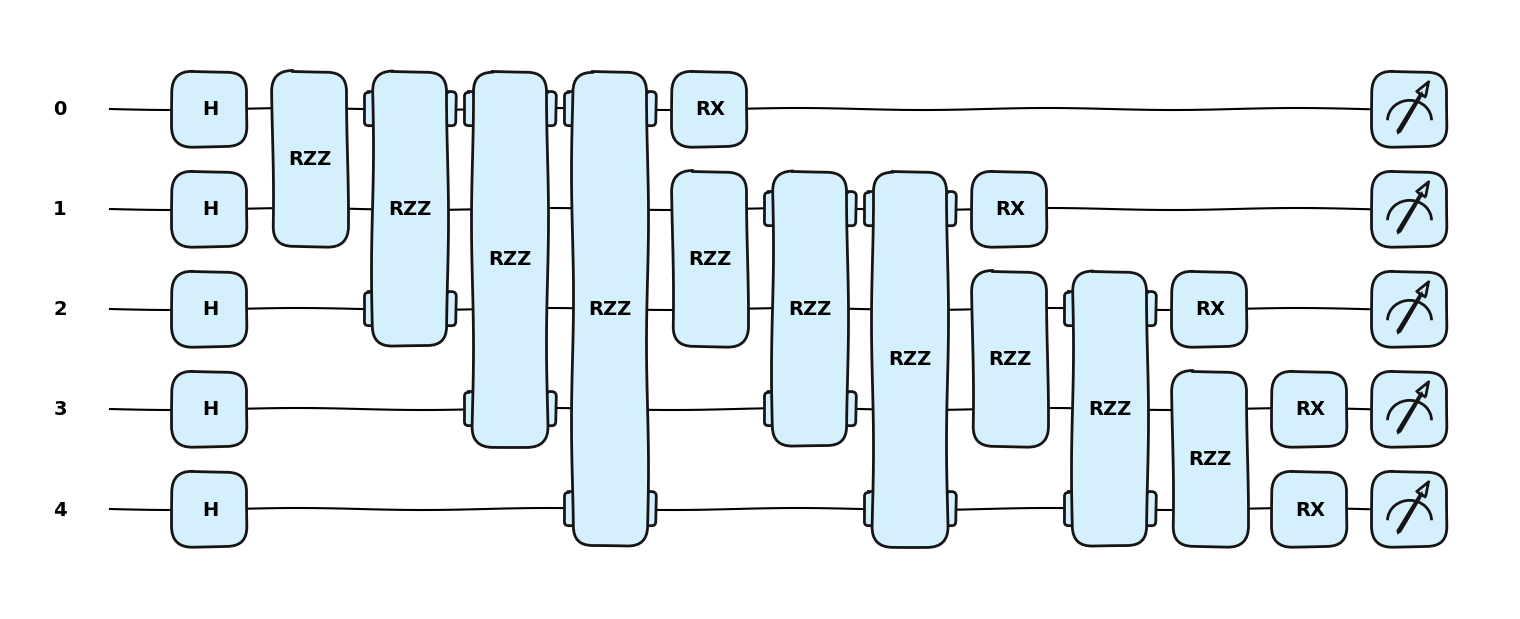

In [ ]:
# Parámetros iniciales
params_init = np.array([[0.1], [0.1]], requires_grad=True)

# Gráfico del circuito, con los valores iniciales de los parámetros
qml.drawer.use_style("pennylane_sketch")
_ = qml.draw_mpl(qaoa_circuit, level=2)(params_init)

**Observaciones:**

En el circuito se puede ver de primera mano la superposición inicial de todos los estados utilizando la compuerta Hadamard.

Luego, también se puede notar las compuertas de Pauli $Z_i \otimes Z_j$ entre los qubits, que constituyen en conjunto compuertas de dos qubits. Estas corresponden al Hamiltoniano de costo, que es el que se relaciona con la función de optimización.

Finalmente, después de las compuertas $Z$, vemos las compuertas de Pauli $X$ en cada qubit, y esto constituye al Hamiltoniano de mezcla.

In [ ]:
params = params_init

# Optimizador clásico
optimizer = qml.AdamOptimizer(stepsize=0.1)

# Proceso de optimización
steps = 100

for i in range(steps):
  params = optimizer.step(qaoa_circuit, params)

  if (i + 1) % 10 == 0:
    energy = qaoa_circuit(params)
    print(f"Step {i+1:3d} | Energy = {energy:.6f}")

Step  10 | Energy = -31.350766
Step  20 | Energy = -32.961429
Step  30 | Energy = -32.664903
Step  40 | Energy = -32.960653
Step  50 | Energy = -33.003519
Step  60 | Energy = -33.001293
Step  70 | Energy = -33.009563
Step  80 | Energy = -33.011397
Step  90 | Energy = -33.012987
Step 100 | Energy = -33.013538


In [ ]:
# Resultados finales del proceso de minimización de energía

final_energy = qaoa_circuit(params)
gamma_param = params[0,0]
beta_param = params[1,0]

print(f"\nPárametros óptimos: γ={gamma_param:.4f}, β={beta_param:.4f}")

print(f"\nEnergía del estado fundamental: {final_energy:.4f}")

# Guardamos los parámetros variacionales en un archivo de texto
file_params = "qaoa_optimized_parameters.txt"

with open(file_params, "w") as f:
    f.write("gamma, beta\n")
    f.write(f"{gamma_param:.4f}, {beta_param:.4f}\n")

print(f"Parámetros variacionales óptimos guardados en {file_params}")


Párametros óptimos: γ=0.4057, β=0.2858

Energía del estado fundamental: -33.0135
Parámetros variacionales óptimos guardados en qaoa_optimized_parameters.txt


In [ ]:
gamma_param = params[0,0]
beta_param = params[1,0]

file_params = "qaoa_optimized_parameters.txt"

with open(file_params, "w") as f:
    f.write(f"gamma={gamma_param:.4f}\n")
    f.write(f"beta={beta_param:.4f}\n")

print(f"Parámetros variacionales óptimos guardados en {file_params}")

Parámetros variacionales óptimos guardados en qaoa_optimized_parameters.txt


8. Para dichos parámetros, obtenga la asignación final de frecuencias de operación para la flota de cinco (5) drones.

    - Para ello, ejecute nuevamente su circuito cuántico con los parámetros finales obtenidos, seleccionando esta vez la obtención de diferentes muestras de mediciones finales del circuito ( **samples()** ), o una distribución de probabilidades de las diversas combinaciones binarias $x_1x_2x_3x_4x_5$ ( **probs()** ).


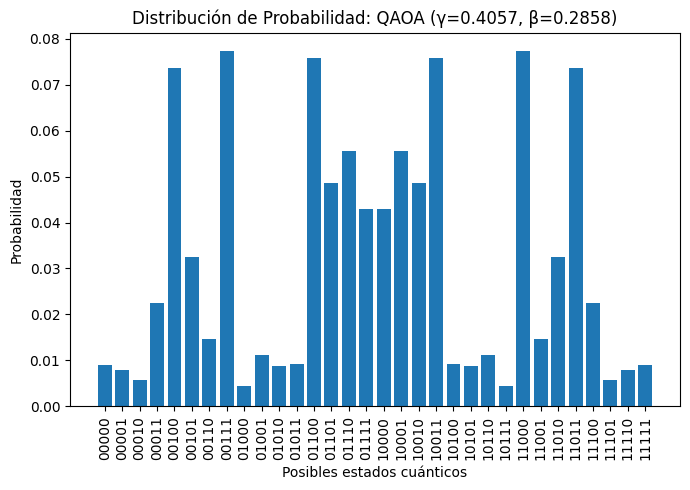

In [ ]:
# ----------- Distribución de probabilidad ----------------------
# Reconstruimos el circuito con los parámetros óptimos
#
@qml.qnode(dev)
def qaoa_probabilities(params):
  # Estado inicial de superposición
  qubits = dev.wires

  for wire in qubits:
    qml.Hadamard(wires=wire)

  for i in range(p):
    qaoa_layer(params[0][i], params[1][i])

  return qml.probs(wires=qubits)

probs = qaoa_probabilities(params)

# Al tener 5 qubits, tenemos 2**5 posibles estados
n_qubits = len(dev.wires)

# Generar etiquetas para los estados ('00000', '00001', ..., '11111')
labels = [np.binary_repr(i, width=n_qubits) for i in range(2**n_qubits)]

plt.figure(figsize=(7, 5))
plt.bar(labels, probs) #, label=f'β={params[0,0]:.4f}, γ={params[1,0]:.4f}')
plt.xlabel("Posibles estados cuánticos")
plt.ylabel("Probabilidad")
plt.title(f"Distribución de Probabilidad: QAOA (γ={params[0,0]:.4f}, β={params[1,0]:.4f})")
plt.xticks(rotation=90)
plt.tight_layout()

In [ ]:
num_states = 5

sorted_indices = np.argsort(probs)[::-1]

# Seleccionar los índices de los `num_states` estados con mayor probabilidad
states_idx = sorted_indices[:num_states]

print(f"\nLos {num_states} estados con las probabilidades más altas son:")
for i in states_idx:
    state_label = labels[i]
    probability = probs[i]
    print(f"Estado |{state_label}>: Probabilidad = {probability:.4f}")

print("\nAsignación de canales para estos estados:")
for i in states_idx:
    state_label = labels[i]

    # Si x_i = 0 -> Canal A, sino Canal B)
    channel_assignment = []
    for bit in state_label:
      channel_assignment.append('A' if bit == '0' else 'B')

    print(f"Estado |{state_label}>: Asignación de canales: {channel_assignment}")


Los 5 estados con las probabilidades más altas son:
Estado |11000>: Probabilidad = 0.0774
Estado |00111>: Probabilidad = 0.0774
Estado |01100>: Probabilidad = 0.0759
Estado |10011>: Probabilidad = 0.0759
Estado |11011>: Probabilidad = 0.0736

Asignación de canales para estos estados:
Estado |11000>: Asignación de canales: ['B', 'B', 'A', 'A', 'A']
Estado |00111>: Asignación de canales: ['A', 'A', 'B', 'B', 'B']
Estado |01100>: Asignación de canales: ['A', 'B', 'B', 'A', 'A']
Estado |10011>: Asignación de canales: ['B', 'A', 'A', 'B', 'B']
Estado |11011>: Asignación de canales: ['B', 'B', 'A', 'B', 'B']


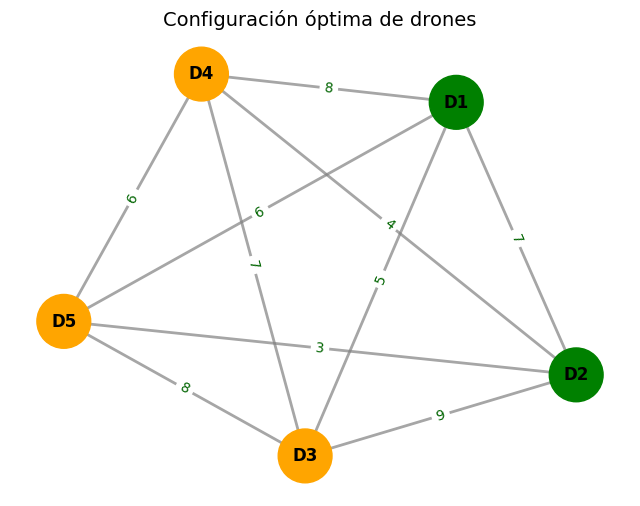

In [ ]:
final_state = '11000'
channel_assignment = ['B', 'B', 'A', 'A', 'A']
node_colors = ['g', 'g', 'orange', 'orange', 'orange']

G = nx.Graph(A.copy())

node_labels = {i: f'D{i+1}' for i in range(len(A))}

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12, font_weight='bold', font_color='black')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='darkgreen')

plt.title(f'Configuración óptima de drones', fontsize=14)
plt.axis('off')
plt.show()